In [1]:
import fastf1
from fastf1.core import Laps

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import init_notebook_mode

init_notebook_mode(connected=True)

## Notebook Configurations

In [2]:
# Columns that are dropped from the Raw Laps Dataframe
DROP_COLS = [
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", 
    "LapStartTime", "Time", "FastF1Generated", "IsAccurate", "DeletedReason"
]

# Order for the Stint Category to be followed in the Facets
STINT_ORDER = {
    "Stint": [1.0, 2.0, 3.0, 4.0]
}

# Hover Data to be displayed for each datapoint for each driver
HOVER_DATA = ["Driver", "LapNumber", "Position", "Compound", "TrackStatus"]

# Driver Number to Short Name mapping for downstream tasks.
DRIVER_NUMBER_MAP = {
    "1": "VER",
    "81": "PIA",
    "63": "RUS",
    "16": "LEC",
    "12": "ANT",
    "55": "SAI",
    "44": "HAM",
    "22": "TSU",
    "10": "GAS",
    "4": "NOR",
    "23": "ALB",
    "30": "LAW",
    "14": "ALO",
    "6": "HAD",
    "87": "BEA",
    "18": "STR",
    "7": "DOO",
    "27": "HUL",
    "31": "OCO",
    "5": "BOR"
}

## Notebook Utilities
- Especially useful for building cohesive classes for easier plotting and construction of data pipelines.

In [3]:
class DataUtils:
    """This class provides the semantic structure for multiple data utility functions to
    ensure the consistency of Data Cleaning and Engineering by constructing a robust, customisable
    data pipeline."""

    # ======================== Class Level variables to perform Tyre Degradation Ops ========================
    # Maximum Fuel Load permissible for the car (110 KG)
    max_fuel_load = 110

    # Fuel Burn kg - per/second (27.8g per/sec)
    fuel_burn_rate = 27.8 * 1e-3

    # Fuel Load to Weight Constant (10Kg => 0.3sec)
    fuel_load_constant = 0.3 * 1e-1

    # Internal Combustion Contribution through a Lap
    ice_const = 0.8

    # ======================== Semantically Relevant Methods for operating on Data ========================

    @staticmethod
    def get_processed_laps(race_laps: Laps, drop_cols: list = DROP_COLS) -> Laps:
        """Processes the raw lap data and provides a more clean version of the race laps
        while maintaining the FastF1 Laps structure."""

        # Dropping InPlace
        race_laps = race_laps.drop(drop_cols, axis=1)

        # Changing the Lap and Sector Times from TimeDelta to Seconds
        lap_cols = ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]
        for col in lap_cols:
            race_laps[col] = race_laps[col].apply(lambda x: x.total_seconds())

        return race_laps
    
    @staticmethod
    def get_valid_quick_laps(race_laps: Laps) -> Laps:
        """Retrieves all the laps from the race session which are not in / out - laps and 
        are laps set at race-speed by default a threshold of 1.07% the best laptime."""
        
        # Until I have a way to model the fuel flow, stick to WO-Box for filtering laps
        return (
            race_laps
            .pick_wo_box()
            .pick_quicklaps(threshold=1.1).copy()
        )
    
    @staticmethod
    def add_tyre_deg_variables(race_laps: Laps, driver_compound_col: bool = False) -> Laps:
        """Utilised the processed raw lap data to calculate necessary tyre degradation variables:
        - Fuel Burn Per/Lap
        - Cumulative Fuel Burn for the race
        - Fuel-Corrected Lap Time for isolated car & driver level basis for tyre degradation 
        independant of the weather variables."""

        # Accessing valid quick race laps
        quick_race_laps = DataUtils.get_valid_quick_laps(race_laps=race_laps)

        # Fuel burnt during any given lap
        quick_race_laps["LapFuelBurnt"] = quick_race_laps["LapTime"] * DataUtils.fuel_burn_rate * DataUtils.ice_const

        # Cumulative fuel burnt by a driver during the race
        quick_race_laps["CumulativeFuelBurnt"] = quick_race_laps.groupby(["Driver"])["LapFuelBurnt"].cumsum()

        # Fuel burnt to the nth lap
        fuel_burnt_before_lap_n = quick_race_laps.groupby(["Driver"])["CumulativeFuelBurnt"].shift(1).fillna(0)

        # The Fuel Aware Laptime
        fuel_load_start_lap_n = DataUtils.max_fuel_load - fuel_burnt_before_lap_n
        fuel_penality_for_lap = fuel_load_start_lap_n * DataUtils.fuel_load_constant
        quick_race_laps["FuelAwareLapTime"] = quick_race_laps["LapTime"] - fuel_penality_for_lap

        # Driver Compound for Stint used in Seaborn
        if driver_compound_col:
            quick_race_laps["DriverCompoundForStint"] = (
                quick_race_laps["Driver"]
                .str
                .cat(quick_race_laps["Compound"], sep="-")
            )

        return quick_race_laps

In [4]:
class PlotUtils:
    """This class provides the semantic structure for multiple plotting functions to ease the 
    visualisations that are made throughout the notebook."""

    @staticmethod
    def plot_line_chart(
        data_frame: pd.DataFrame, 
        X: np.ndarray | pd.Series | str, 
        y: np.ndarray | pd.Series | str, 
        label: np.ndarray | pd.Series | str | None,
        title: str,
        **kwargs
    ) -> None:
        """A helper function to efficiently plot multiple line charts using Plotly."""

        # Plotly Line Chart
        fig = px.line(
            data_frame=data_frame,
            x=X,
            y=y,
            color=label,
            labels=label,
            title=title,
            width=1540,
            height=kwargs["height"] if kwargs else 720,
            facet_row=kwargs["facet_row"] if kwargs else None,
            category_orders=kwargs["category_orders"] if kwargs else None,
            hover_data=kwargs["hover_data"] if kwargs else None,
            symbol=kwargs["marker"] if kwargs else None
        )

        fig.show()

    @staticmethod
    def plot_reg_chart(
        data_frame: pd.DataFrame,
        facet_row: str,
        X: np.ndarray | pd.Series | str,
        y: np.ndarray | pd.Series | str,
        label: str,
        order: int,
        title: str
    ) -> None:
        """A helper function to efficiently multiple regression charts using Seaborn."""

        # Facet Grid to layout the Regression Charts
        reg_grid = sns.FacetGrid(
            data=data_frame,
            row=facet_row,
            hue=label,
            sharex=False,
            sharey=False,
            height=5,
            aspect=3
        )

        # Creating the Regression Charts
        reg_grid.map_dataframe(
            sns.regplot,
            x=X,
            y=y,
            order=order
        )

        # Plot Anatomy
        for ax in reg_grid.axes.flatten():
            ax.legend()
            ax.grid()

        # Title of the Chart
        reg_grid.figure.suptitle(t=title, y=1.05)

        plt.show()

In [5]:
# Creating instances of all the Utility Objects
data_pipe = DataUtils()
plotter = PlotUtils()

## Loading the Data

In [6]:
brazil_2025 = fastf1.get_event(
    year=2025,
    gp="Brazil"
)

brazil_2025

req         WARNING 	DEFAULT CACHE ENABLED! (327.55 MB) /Users/purplelightning/Library/Caches/fastf1


RoundNumber                                                         21
Country                                                         Brazil
Location                                                     São Paulo
OfficialEventName    FORMULA 1 MSC CRUISES GRANDE PRÊMIO DE SÃO PAU...
EventDate                                          2025-11-09 00:00:00
EventName                                         São Paulo Grand Prix
EventFormat                                          sprint_qualifying
Session1                                                    Practice 1
Session1Date                                 2025-11-07 11:30:00-03:00
Session1DateUtc                                    2025-11-07 14:30:00
Session2                                             Sprint Qualifying
Session2Date                                 2025-11-07 15:30:00-03:00
Session2DateUtc                                    2025-11-07 18:30:00
Session3                                                        Sprint
Sessio

## Accessing the Race Session

In [7]:
brazil_race = brazil_2025.get_race()

brazil_race.load(
    laps=True,
    telemetry=True,
    weather=True,
    messages=True
)

core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '12', '1', '63', '81', '87', '30', '6', '27', '10', '23', '3

In [8]:
# Accessing the race laps
race_laps = brazil_race.laps

# Cleaning the Data using the Pipeline
race_laps = data_pipe.get_processed_laps(race_laps=race_laps)
race_laps.head()

,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartDate,TrackStatus,Position,Deleted
0,VER,1,87.191,1.0,1.0,0 days 00:57:08.347000,NaT,NaN,39.288,17.131,...,NaN,False,HARD,1.0,True,Red Bull Racing,2025-11-09 17:03:14.079,12,18.0,False
1,VER,1,120.413,2.0,1.0,NaT,NaT,21.320,75.859,23.234,...,271.0,True,HARD,2.0,True,Red Bull Racing,2025-11-09 17:04:41.462,24,17.0,False
2,VER,1,109.007,3.0,1.0,NaT,NaT,21.675,58.682,28.650,...,258.0,True,HARD,3.0,True,Red Bull Racing,2025-11-09 17:06:41.875,4,16.0,False
3,VER,1,106.620,4.0,1.0,NaT,NaT,25.318,59.748,21.554,...,237.0,True,HARD,4.0,True,Red Bull Racing,2025-11-09 17:08:30.882,4,16.0,False
4,VER,1,107.889,5.0,1.0,NaT,NaT,30.078,50.463,27.348,...,247.0,False,HARD,5.0,True,Red Bull Racing,2025-11-09 17:10:17.502,41,16.0,False


In [9]:
# Querying the data for Top 5 Drivers
top_5_drivers = race_laps[
    (race_laps["Position"] >= 1) &
    (race_laps["Position"] <= 5) &
    (race_laps["LapNumber"] == 70)
]["Driver"].unique()

# Plotting the Position Progression of Drivers in Top 5
plotter.plot_line_chart(
    data_frame=race_laps[
        race_laps["Driver"].isin(top_5_drivers)
    ],
    X="LapNumber",
    y="Position",
    label="Driver",
    title="Driver Position Progression throughout the Race (Top 5)"
)

## Analysing the Tyre Degradation

**Key Assumptions Made**
- Due to the lack of hybrid energy and ICE deployment data I have ignored the contribution of the hybrid in pace calculation and enforced a weighted constant for ICE contribution as per the previous regulations (2022 - 2025) where:
    - *ICE contributes 80% of the power while the hybrid system contributes 20% of the power*
- While car telemetry data is available, it wasn't available for the race session and hence the fuel burn calculation is laid out for the worst case scenario i.e, the max fuel-flow is being utilsed every second of the lap. Thus, every lap in this racing world is hence is near push lap which punishes bad tyre degradation further.
- I have chosen to focus on the top 5 by calculating the mean position of a driver throughout the race (lower is better) since the front of the pack is in resonably clean air and in the contention for a race win leaving nothing in the cockpit.

In [10]:
# Applying the transforms for creating tyre degradation features
quick_race_laps = data_pipe.add_tyre_deg_variables(race_laps=race_laps, driver_compound_col=True)

# Selecting the top 5 finishers
filtered_quick_race_laps = quick_race_laps.pick_drivers(top_5_drivers)
filtered_quick_race_laps

,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,...,FreshTyre,Team,LapStartDate,TrackStatus,Position,Deleted,LapFuelBurnt,CumulativeFuelBurnt,FuelAwareLapTime,DriverCompoundForStint
5,VER,1,78.495,6.0,1.0,NaT,NaT,20.374,40.996,17.125,...,True,Red Bull Racing,2025-11-09 17:12:05.391,12,13.0,False,1.745729,1.745729,75.195000,VER-HARD
8,VER,1,73.141,9.0,2.0,NaT,NaT,18.886,37.345,16.910,...,True,Red Bull Racing,2025-11-09 17:16:55.695,1,16.0,False,1.626656,3.372385,69.893372,VER-MEDIUM
9,VER,1,73.049,10.0,2.0,NaT,NaT,18.826,37.385,16.838,...,True,Red Bull Racing,2025-11-09 17:18:08.836,1,16.0,False,1.624610,4.996994,69.850172,VER-MEDIUM
10,VER,1,73.735,11.0,2.0,NaT,NaT,18.826,38.060,16.849,...,True,Red Bull Racing,2025-11-09 17:19:21.885,1,16.0,False,1.639866,6.636861,70.584910,VER-MEDIUM
11,VER,1,74.816,12.0,2.0,NaT,NaT,18.756,39.077,16.983,...,True,Red Bull Racing,2025-11-09 17:20:35.620,1,16.0,False,1.663908,8.300769,71.715106,VER-MEDIUM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,PIA,81,73.734,67.0,3.0,NaT,NaT,18.857,38.111,16.766,...,False,McLaren,2025-11-09 18:29:23.261,1,5.0,False,1.639844,92.500897,73.159832,PIA-MEDIUM
1176,PIA,81,73.661,68.0,3.0,NaT,NaT,18.934,38.083,16.644,...,False,McLaren,2025-11-09 18:30:36.995,1,5.0,False,1.638221,94.139118,73.136027,PIA-MEDIUM
1177,PIA,81,73.342,69.0,3.0,NaT,NaT,18.663,38.098,16.581,...,False,McLaren,2025-11-09 18:31:50.656,1,5.0,False,1.631126,95.770244,72.866174,PIA-MEDIUM
1178,PIA,81,73.702,70.0,3.0,NaT,NaT,18.803,38.093,16.806,...,False,McLaren,2025-11-09 18:33:03.998,1,5.0,False,1.639132,97.409376,73.275107,PIA-MEDIUM


In [11]:
# Verifying the fuel consumption for each of the drivers
filtered_quick_race_laps.groupby(["Driver", "Stint"])["CumulativeFuelBurnt"].last()

Driver  Stint
ANT     1.0       23.466002
        2.0       63.233146
        3.0      100.887290
NOR     1.0       38.252422
        2.0       68.005628
        3.0      100.675743
PIA     1.0       50.056235
        2.0       68.067188
        3.0       99.053268
RUS     1.0       43.518120
        2.0       63.237683
        3.0       99.313276
VER     1.0        1.745729
        2.0       43.410945
        3.0       72.929697
        4.0       98.988127
Name: CumulativeFuelBurnt, dtype: float64

## Visualisations

### Full Lap Pace with respect to stint for the Front Runners

In [12]:
plotter.plot_line_chart(
    data_frame=filtered_quick_race_laps,
    X="LapNumber",
    y="FuelAwareLapTime",
    label="Driver",
    title="Pure Pace of the Front Runner over a Full Lap in Race Distance",
    facet_row="Stint",
    category_orders=STINT_ORDER,
    hover_data=HOVER_DATA,
    marker="Compound",
    height=1080,
)

**Inference**
- Stint - 1:
    >Note:
    >- During the stint all the front runners were pushing and thus had identical pace over a full lap due to the early safety car resetting the strategies and providing opportunities for back-markers especially Verstappen.
    >- Verstappen however, had to pit early due to a puncture under the safety car while all the others maintained track position. 
    >- Thus the front-runners were thus able to maintain tyre temps to get on pace quickly after the safety car to rebuild their margins.  

    - Verstappen: On the Hards due to pit-lane start enforcing a long first stint however, anticlimactically he picks up a puncture due to debris during the safety car thereby making his first stint very short despite coming upto 13th position.
    - Norris: On Pole position was off to a flier in lap-9 when the track was back to green in comparison to all the other front runners on the same compound. Further the aero-efficiency of the McLaren meant he was quickly up the road and retained the best pace on the Mediums in Clean Air.
    - Piastri: The closest pace to Norris but due to the poor safety car restart (Collision with Antonelli and Leclerc which I frankly thought was a racing incident) the damage was already done for him in this stint as in the first 3 tours alone he lost 1.2secs and the lock-up during the incident meant he couldn't gain back time under green flag. However, despite the flat-spot his pace after the restart was only second to Norris.
    - Antonelli and Russell: Between the two Mercedes drivers the pace gains on Soft, Medium respectively was not significant. However, Antonelli on the Softs was more vulnerable to early tyre degradation while Russell went consistently longer on his Mediums matching Piastri early and Later in the stint. Provisionally, the gap between Russell and Piastri mid stint could be conservation from Russell to save grip for later in the stint.

- Stint - 2:
    - Verstappen: This stint can be considered his equivalent to the 1st Stint wrt the front-runners. He had a critical lap few laps at the start of the stint (plausibly to catchup on the gaps on track) after which he settled into the stint while cutting through the mid field. He was quick and decisive with his passes while maintaining pace that is comparable to Piastri in stint - 1.
    - Norris: On the softer compound with higher vulnerability to tyre degradation he maintained a steady pace. However, interestingly (maybe due to conservation and delayed startegy calls in McLaren) his pace was not significantly faster than used Mediums.
    - Piastri: On the softer compound aswell he had a much better stint in comparison to Norris in terms of pure pace. Having lost track position to a penality, his pace was 0.8~1.6sec/lap quicker to Norris. Could be attributed to clearer strategy calls for pushing the tyres coupled with good tyre warm-up.
    - Antonelli: He pitted first among the front-runners (plausibly due to flat-spots / dirty tyres during safety car restart) and thus went longer on Mediums. However, track position wasn't easy for him as the spikes in pace were clear losses in race-time battling to gain track position. Despite the battles his pace wasn't too bad being comparable to Norris (provisionally in clean air).
    - Russell: On a similar strategy to Piastri pushed his soft tyres to regain strategic superiority (track-position) without needing to conserve his tyre as much. However, the line between Piastri and Russell indicate better tyre management from Piastri and the McLaren (ablation based on sectors below).

- Stint - 3:
    >Note:
    >- During this stint we can see track evolution kick-in as everyone is on comparable pace on the Mediums.
    >- Furthermore, due to the track-evolution the tyre degradation was very similar among all the front-runners.
    >- This is most notable in Mercedes where given the conditions that both drivers faced on track their pace during the stint is highly comparable.

    - Verstappen: Back on the Mediums he was consistent in his pace though he had pitted to have higher tyre energy towards (more overtaking) the end of the race instead of relying on older tyres as everyone else cycled more optimally on their pitstops to finish the race.
    - Norris: He had consistent pace early in the stint however, he never really had to push as he was in clean air. Despite the clean air however, his pace was very variable in the final laps (plausibly eased out).
    - Piastri and Russell: Both the drivers were locked in a race for the final positions in the top 5 where Russell was there through track-position while Piastri had fought his way on track after having served the penality. However, due to long battles on track there pace has been higher than expected with major spikes.
    - Antonelli: He was protected by Russell making his pace within his interval (enough clean air on track) ver consistent. However, he had a battle with Verstappen during the final laps which might have spiked the pace.

- Stint - 4 (Only Verstappen):
    - To battle for podium positions Verstappen and RedBull had opted to pit one final time, securing higher tyre energy with much faster tyres (Softs). Having lost track position (1 -> 4) Verstappen used his tyres to quickly catchup to Russell and make a pass while not bleeding laptime. However, the next position on Antonelli was harder due both the interval and some sublime defending. Verstappen used the pace in his tyres to quickly catch Antonelli however, he couldn't make a pass.

### Tyre Degradation with respect to each Stint in Race Distance over a Full Lap

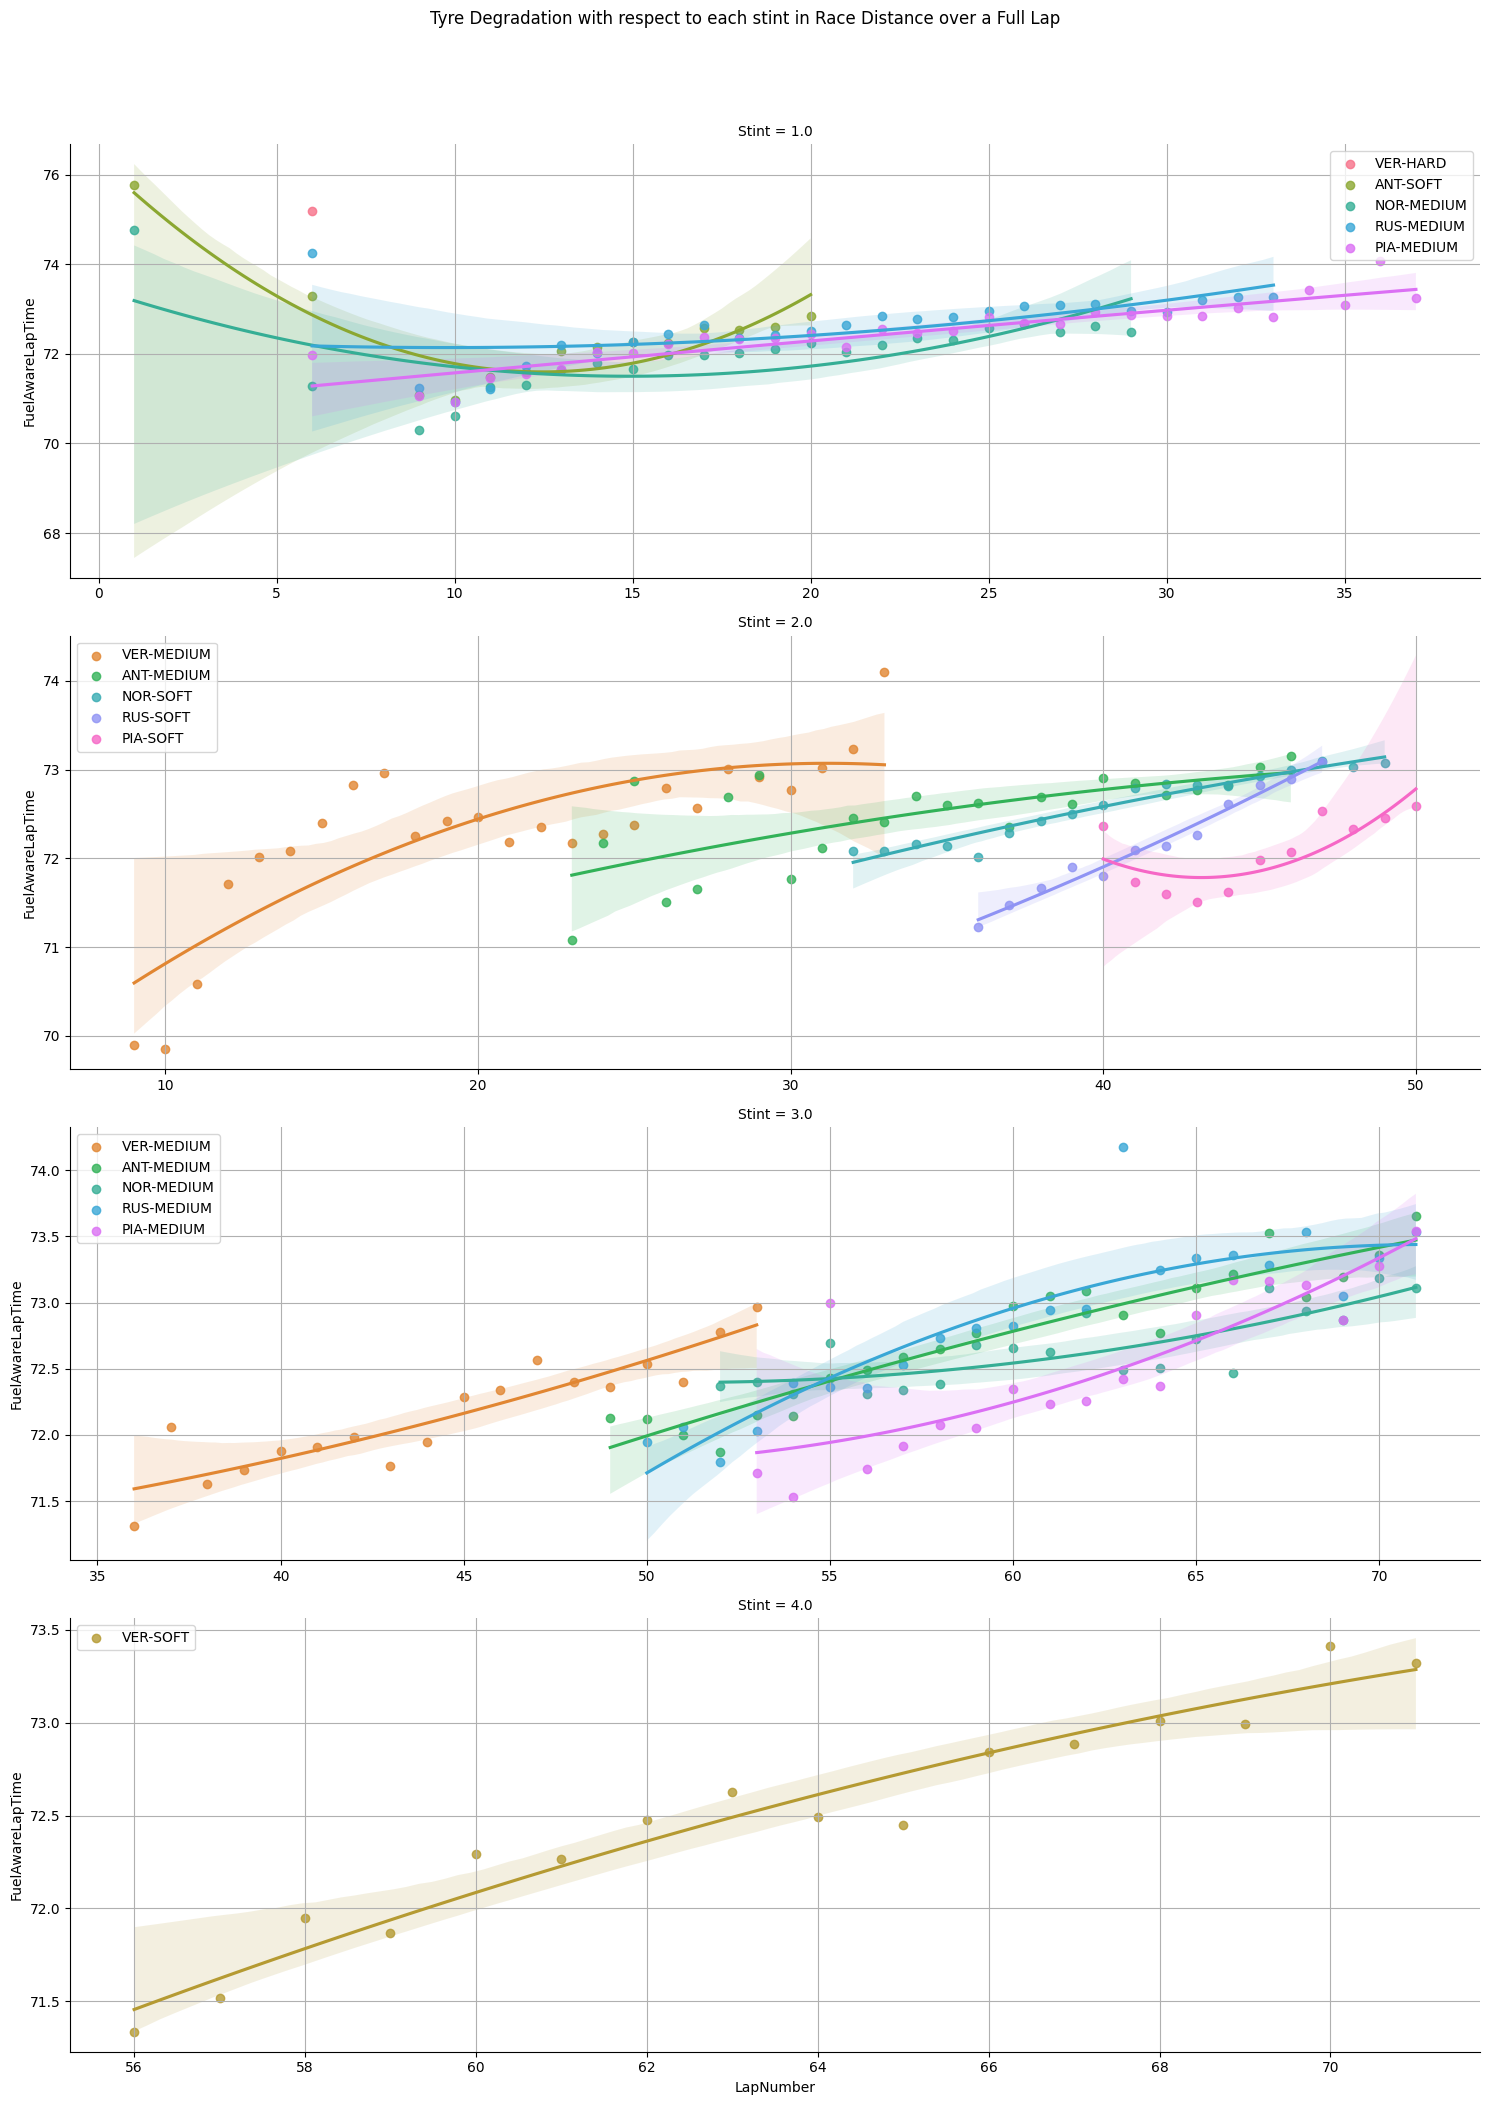

In [13]:
plotter.plot_reg_chart(
    data_frame=filtered_quick_race_laps,
    facet_row="Stint",
    X="LapNumber",
    y="FuelAwareLapTime",
    label="DriverCompoundForStint",
    order=2,
    title="Tyre Degradation with respect to each stint in Race Distance over a Full Lap"
)

### Accessing and Decoupling the Car Telemetry for Analysis

In [14]:
# Accessing the car telemetry for all the drivers
driver_telemetry_data = brazil_race.car_data

# Seperating the telemetry for the top 5 drivers
top_5_telemetry = {}

for driver_num in filtered_quick_race_laps["DriverNumber"].unique():
    driver_name = DRIVER_NUMBER_MAP[driver_num]
    top_5_telemetry[driver_name] = driver_telemetry_data[driver_num]

top_5_telemetry.keys()

dict_keys(['VER', 'ANT', 'NOR', 'RUS', 'PIA'])

In [15]:
# Interpolating the Lap Numbers wrt each drivers green flag race laps
for driver, driver_telemetry in top_5_telemetry.items():
    driver_laps = filtered_quick_race_laps[filtered_quick_race_laps["Driver"] == driver]
    driver_green_laps = driver_laps[driver_laps["TrackStatus"].isin(["1"])].copy()

    # Adding the end date as the window between start date of current lap and subsequent lap for interpolation
    driver_green_laps["LapEndDate"] = driver_green_laps["LapStartDate"].shift(-1).fillna(0)

    # Adding the LapNumber default col to the driver telemetry
    driver_telemetry["LapNumber"] = 0

    # Iterating through each lap in the race
    for lap_idx in range(len(driver_green_laps) - 1):
        lap = driver_green_laps.iloc[lap_idx]

        # Accessing the telemetry samples corresponding to the current race lap
        telemetry_for_lap = driver_telemetry[
            (driver_telemetry["Date"] >= lap["LapStartDate"]) &
            (driver_telemetry["Date"] <= lap["LapEndDate"])
        ].copy()

        # Updating the LapNumber column for all the samples to reflect the lap
        telemetry_for_lap["LapNumber"] = lap["LapNumber"]
        
        # Moving the changes to the original telemetry frame
        driver_telemetry[
            (driver_telemetry["Date"] >= lap["LapStartDate"]) &
            (driver_telemetry["Date"] <= lap["LapEndDate"])
        ] = telemetry_for_lap

In [17]:
ver_tele = top_5_telemetry["VER"]
max_speed = ver_tele["Speed"].max()
max_rpm = ver_tele["RPM"].max()
print(max_speed)
print(max_rpm)

346.0
12591.0


In [48]:
lap_69 = ver_tele[ver_tele["LapNumber"] == 69].copy()
lap_69["NextSpeed"] = lap_69["Speed"].shift(-1).fillna(0)
lap_69["NextSample"] = (lap_69["Date"].dt.microsecond * 1e-6).shift(-1).fillna(0)
lap_69["CurrentSample"] = lap_69["Date"].dt.microsecond * 1e-6
lap_69["Acceleration"] = ((lap_69["NextSpeed"] - lap_69["Speed"]) * 5/18) / (lap_69["NextSample"] - lap_69["CurrentSample"])

lap_69.iloc[:50]

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,LapNumber,NextSpeed,NextSample,CurrentSample,Acceleration
31995,2025-11-09 18:31:45.742,11681.0,330.0,8,100.0,False,12,car,0 days 02:25:26.143000,0 days 02:25:26.143000,69,331.0,0.942,0.742,1.388889
31996,2025-11-09 18:31:45.942,11723.0,331.0,8,100.0,False,12,car,0 days 02:25:26.343000,0 days 02:25:26.343000,69,332.0,0.102,0.942,-0.330688
31997,2025-11-09 18:31:46.102,11749.0,332.0,8,100.0,False,12,car,0 days 02:25:26.503000,0 days 02:25:26.503000,69,332.0,0.302,0.102,0.000000
31998,2025-11-09 18:31:46.302,11705.0,332.0,8,100.0,False,12,car,0 days 02:25:26.703000,0 days 02:25:26.703000,69,333.0,0.583,0.302,0.988533
31999,2025-11-09 18:31:46.583,11762.0,333.0,8,100.0,False,12,car,0 days 02:25:26.984000,0 days 02:25:26.984000,69,334.0,0.903,0.583,0.868056
32000,2025-11-09 18:31:46.903,11852.0,334.0,8,100.0,False,12,car,0 days 02:25:27.304000,0 days 02:25:27.304000,69,335.0,0.103,0.903,-0.347222
32001,2025-11-09 18:31:47.103,11775.0,335.0,8,100.0,False,12,car,0 days 02:25:27.504000,0 days 02:25:27.504000,69,334.0,0.383,0.103,-0.992063
32002,2025-11-09 18:31:47.383,11724.0,334.0,8,100.0,False,12,car,0 days 02:25:27.784000,0 days 02:25:27.784000,69,334.0,0.583,0.383,0.000000
32003,2025-11-09 18:31:47.583,11795.0,334.0,8,100.0,False,12,car,0 days 02:25:27.984000,0 days 02:25:27.984000,69,334.0,0.823,0.583,0.000000
32004,2025-11-09 18:31:47.823,11588.0,334.0,8,53.0,False,12,car,0 days 02:25:28.224000,0 days 02:25:28.224000,69,328.0,0.023,0.823,2.083333


In [20]:
ver_tele = top_5_telemetry["VER"]
ver_tele["RPM"] = (ver_tele["RPM"] / ver_tele["RPM"].max()) * 100
ver_tele["Speed"] = (ver_tele["Speed"] / ver_tele["Speed"].max()) * 100
fig = go.Figure()

lap_number = 70
fig.add_traces(
    go.Scatter(
        x=ver_tele[ver_tele["LapNumber"] == lap_number]["Date"].dt.time,
        y=ver_tele[ver_tele["LapNumber"] == lap_number]["Throttle"],
        name="Throttle"
    )
)
fig.add_traces(
    go.Scatter(
        x=ver_tele[ver_tele["LapNumber"] == lap_number]["Date"].dt.time,
        y=ver_tele[ver_tele["LapNumber"] == lap_number]["RPM"],
        name="RPM"
    )
)
fig.add_traces(
    go.Scatter(
        x=ver_tele[ver_tele["LapNumber"] == lap_number]["Date"].dt.time,
        y=ver_tele[ver_tele["LapNumber"] == lap_number]["Speed"],
        name="Speed"
    )
)

fig.show()

### Understanding Tyre Degradation with respect to Track Layout by Sectors

>Source: F1

![Image of the Interlagos Circuit Layout](../../assets/Brazil_Circuit.png)

### Sector-Wise Pace for each of the Front Runners with respect Stint

#### Sector - 1

In [33]:
plotter.plot_line_chart(
    data_frame=filtered_quick_race_laps,
    X="LapNumber",
    y="Sector1Time",
    label="Driver",
    title="Pace of the Front Runners in Sector - 1",
    facet_row="Stint",
    category_orders=STINT_ORDER,
    hover_data=HOVER_DATA,
    marker="Compound",
    height=1080,
)

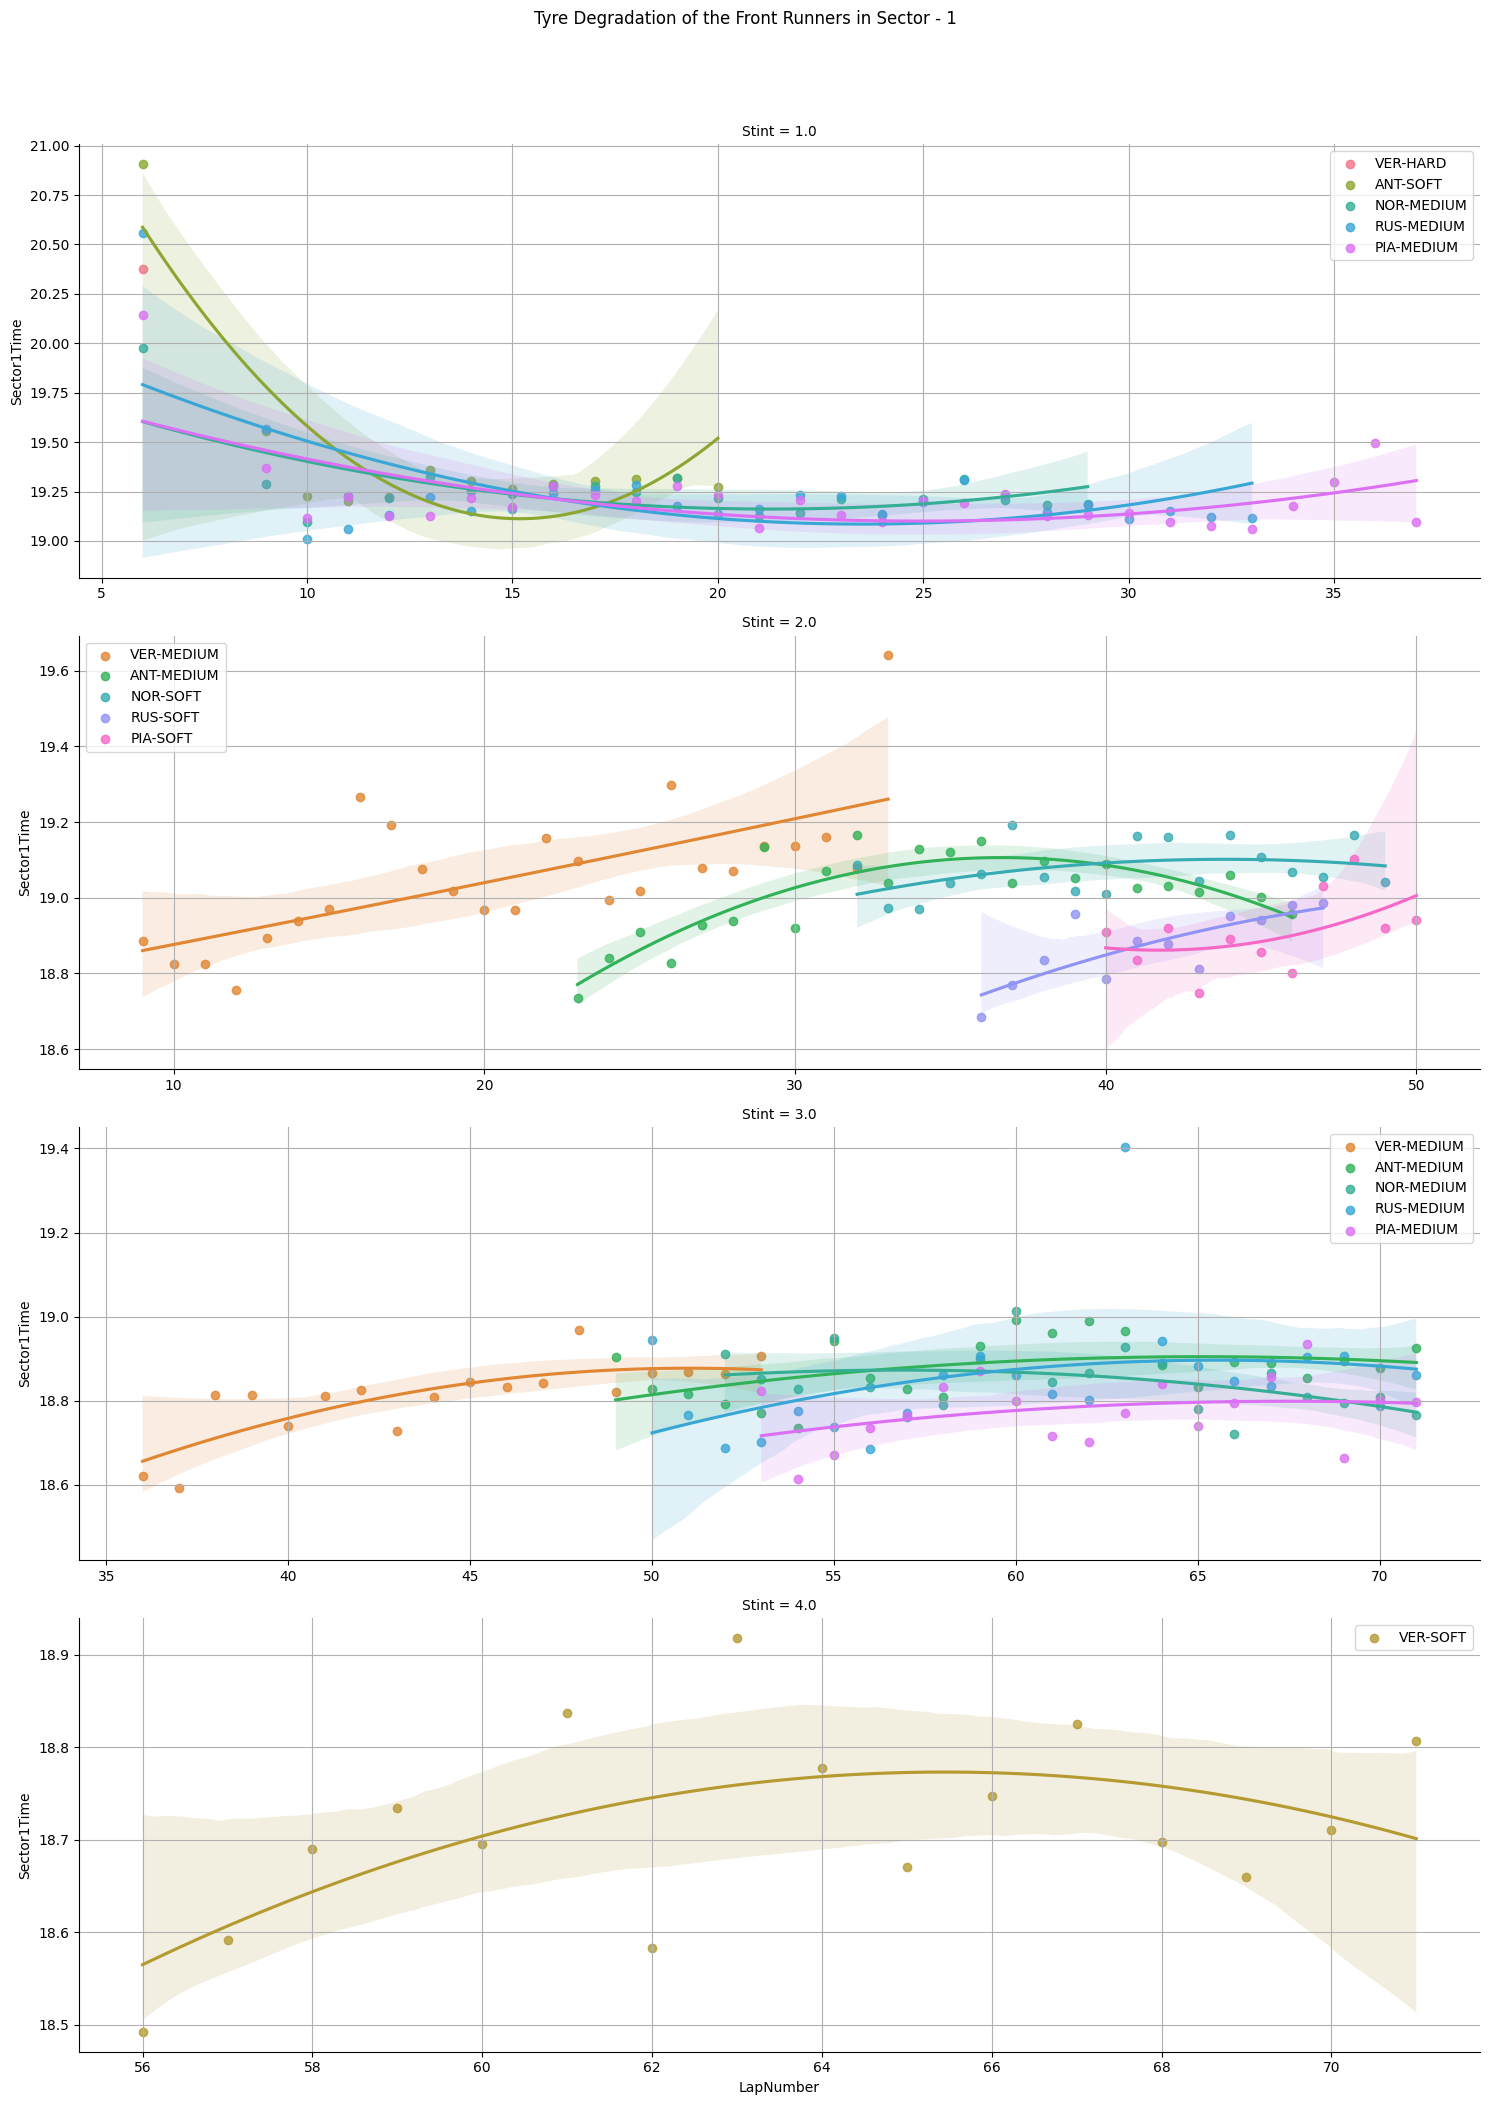

In [41]:
plotter.plot_reg_chart(
    data_frame=filtered_quick_race_laps,
    facet_row="Stint",
    X="LapNumber",
    y="Sector1Time",
    label="DriverCompoundForStint",
    order=2,
    title="Tyre Degradation of the Front Runners in Sector - 1",
)

#### Sector - 2

In [42]:
plotter.plot_line_chart(
    data_frame=filtered_quick_race_laps,
    X="LapNumber",
    y="Sector2Time",
    label="Driver",
    title="Pace of the Front Runners in Sector - 2",
    facet_row="Stint",
    category_orders=STINT_ORDER,
    hover_data=HOVER_DATA,
    marker="Compound",
    height=1080,
)

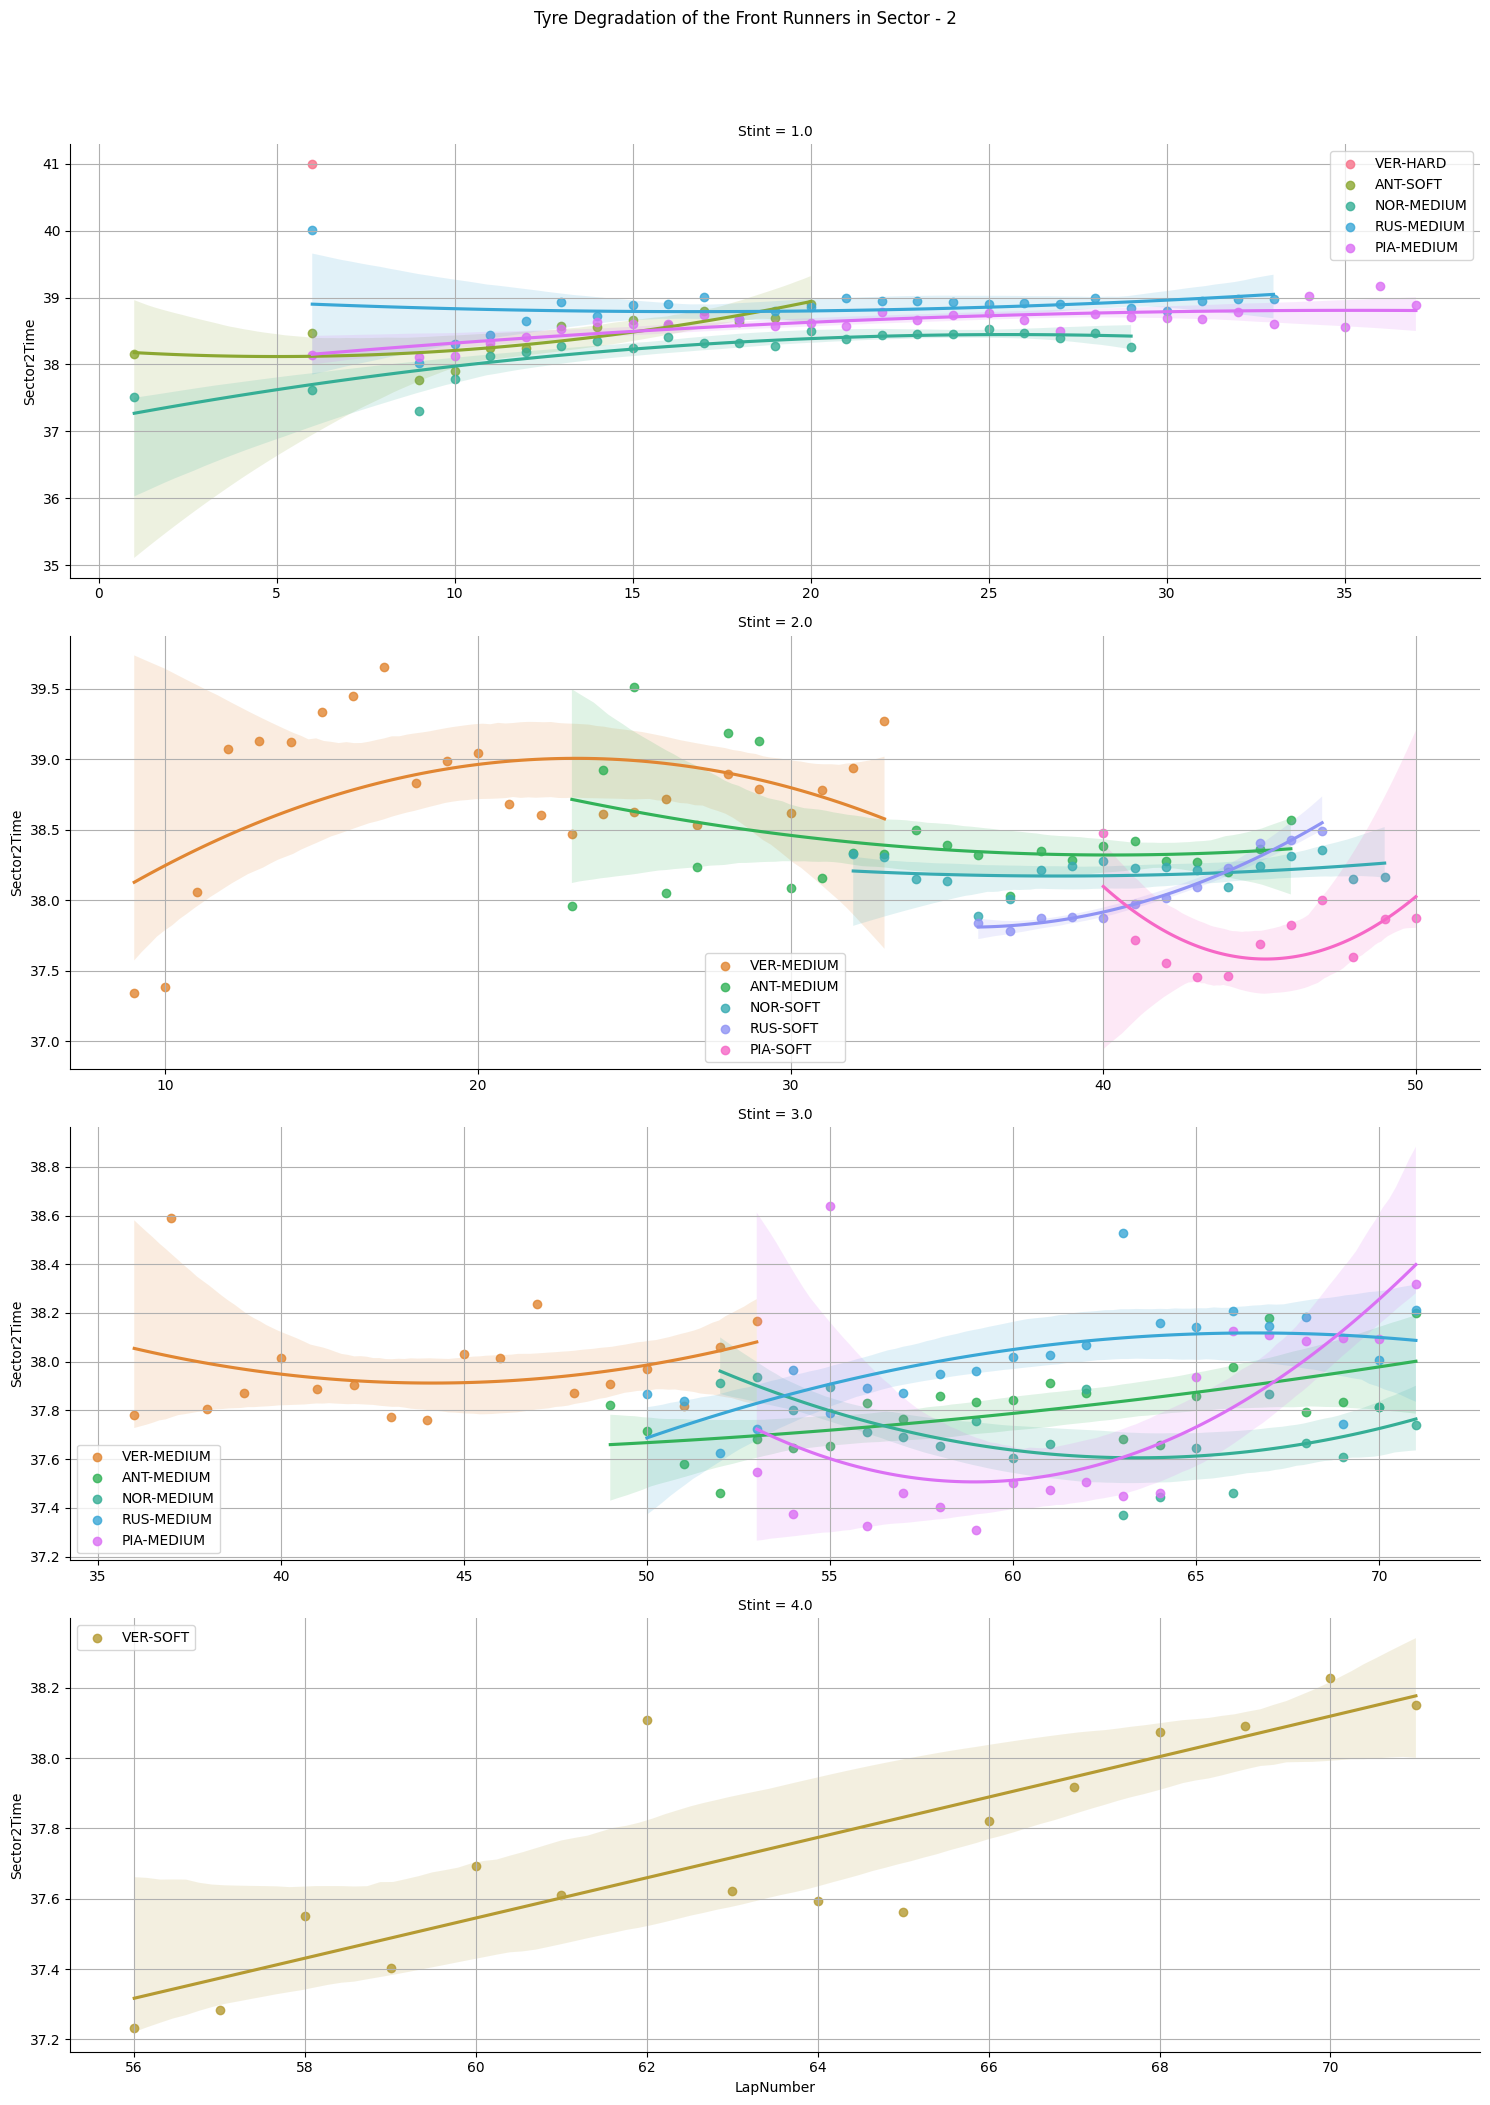

In [43]:
plotter.plot_reg_chart(
    data_frame=filtered_quick_race_laps,
    facet_row="Stint",
    X="LapNumber",
    y="Sector2Time",
    label="DriverCompoundForStint",
    order=2,
    title="Tyre Degradation of the Front Runners in Sector - 2",
)

#### Sector - 3

In [44]:
plotter.plot_line_chart(
    data_frame=filtered_quick_race_laps,
    X="LapNumber",
    y="Sector3Time",
    label="Driver",
    title="Pace of the Front Runners in Sector - 3",
    facet_row="Stint",
    category_orders=STINT_ORDER,
    hover_data=HOVER_DATA,
    marker="Compound",
    height=1080,
)

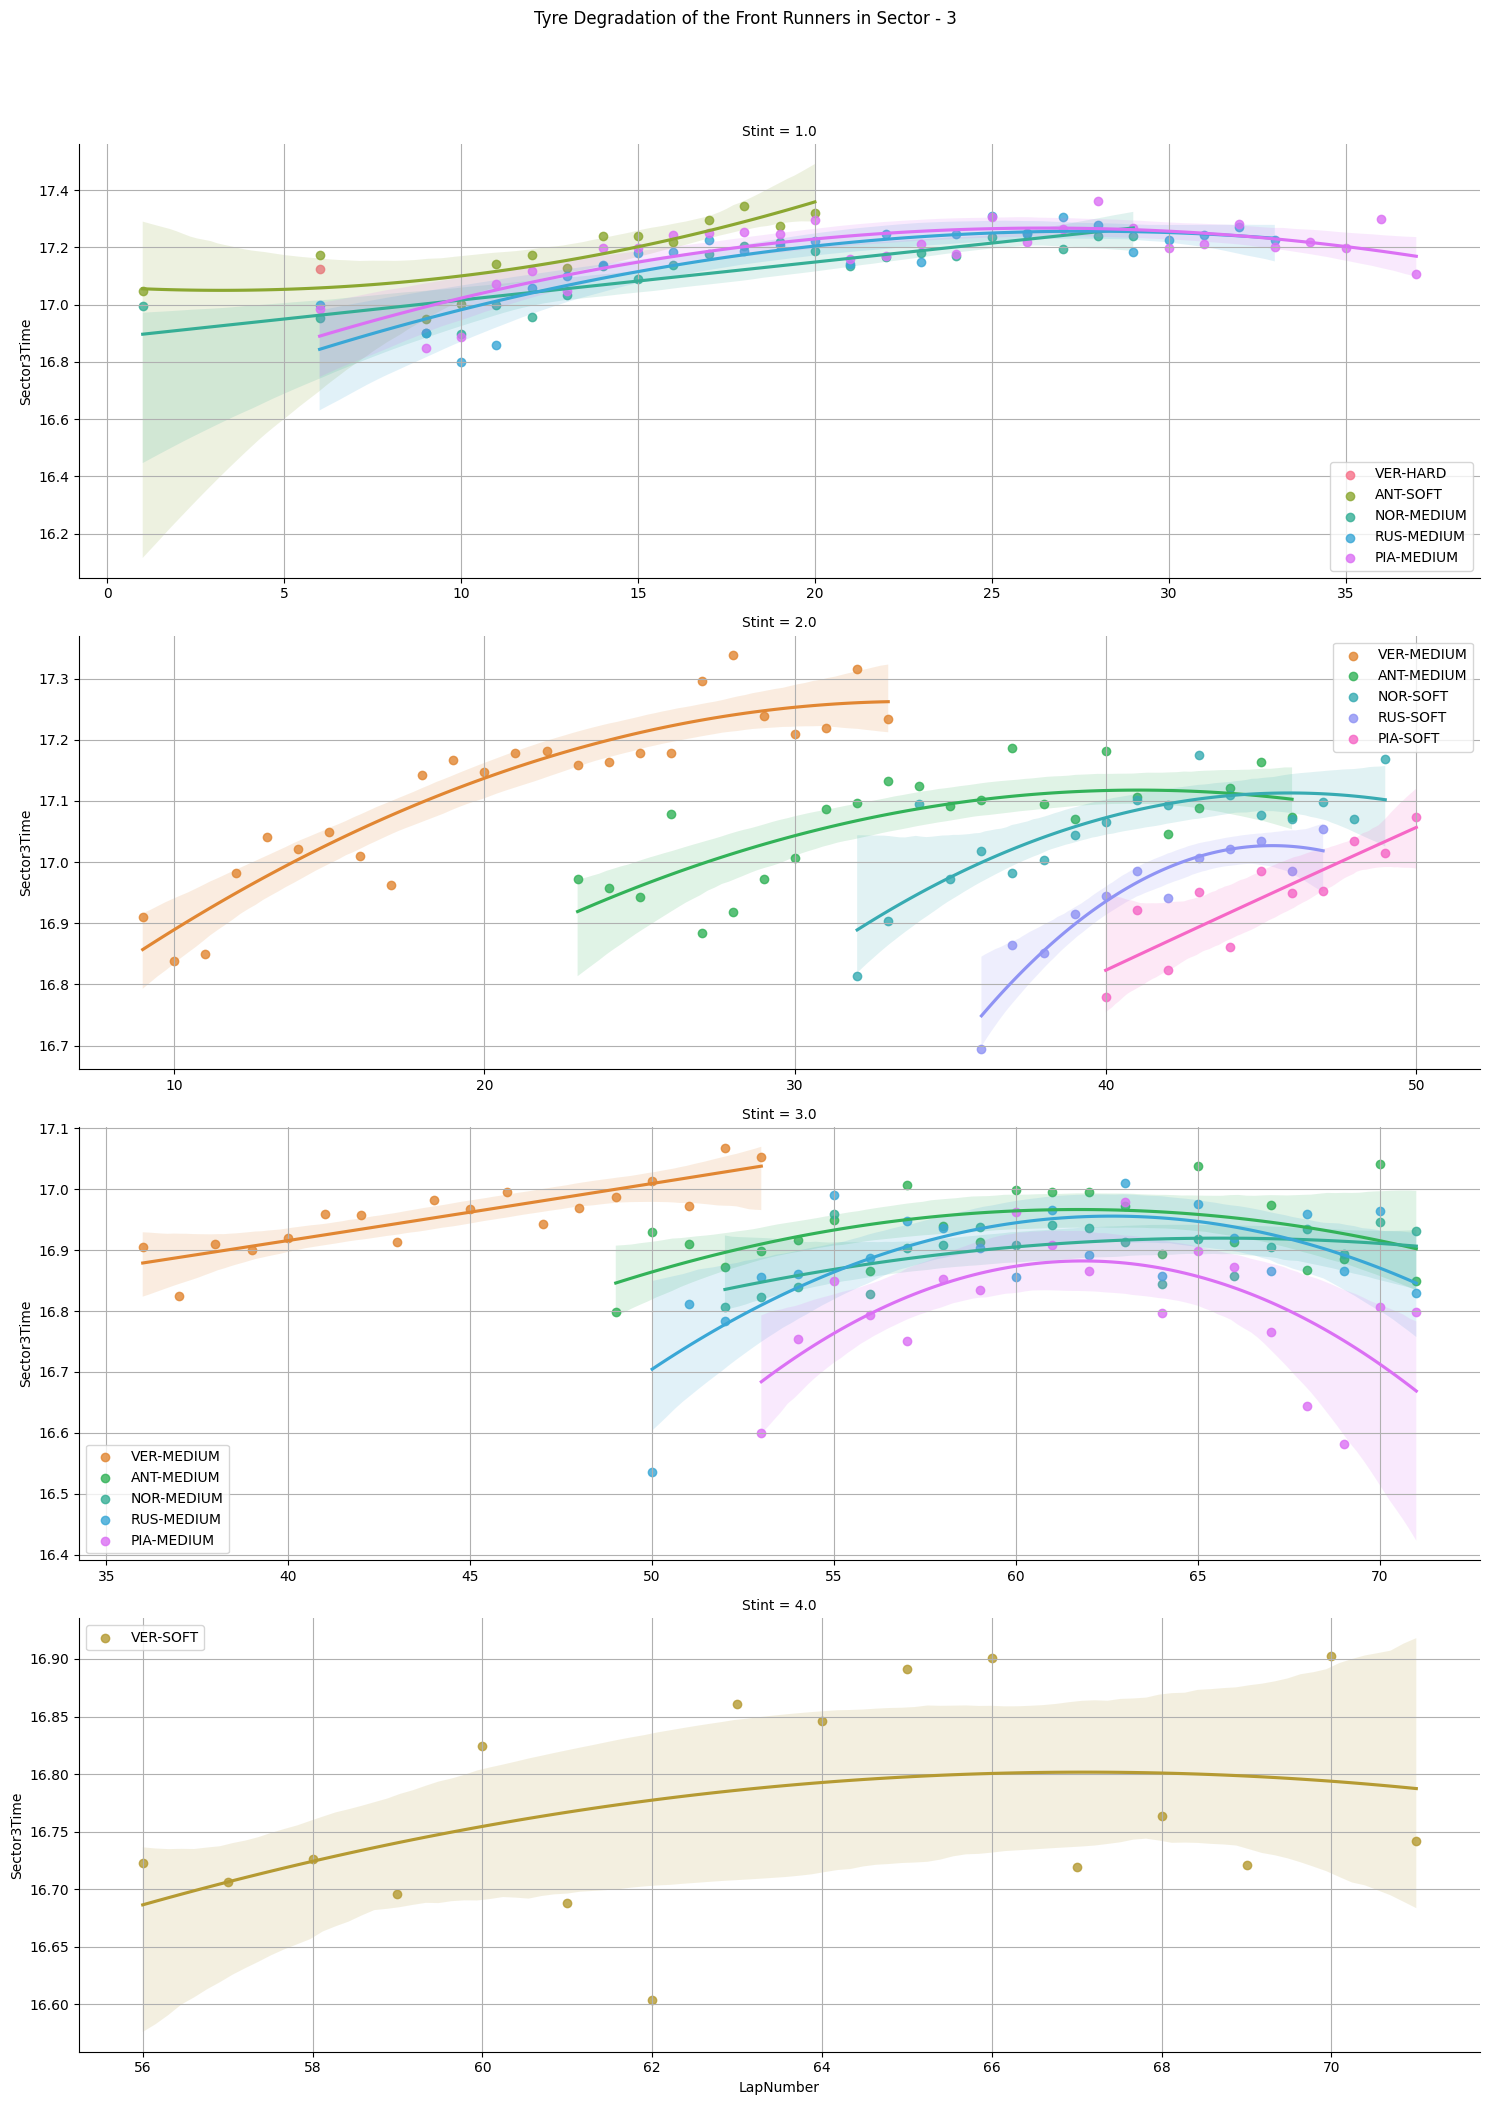

In [45]:
plotter.plot_reg_chart(
    data_frame=filtered_quick_race_laps,
    facet_row="Stint",
    X="LapNumber",
    y="Sector3Time",
    label="DriverCompoundForStint",
    order=2,
    title="Tyre Degradation of the Front Runners in Sector - 3",
)